In [1]:
import pandas as pd
import numpy as np

In [39]:
df = pd.read_csv("powerplant_data.csv")

In [40]:
df.shape

(9568, 5)

In [44]:
X = df.iloc[:,0:-1]
y = df.iloc[:,-1]

In [45]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=40)

In [46]:
X_train.shape,y_train.shape

((7654, 4), (7654,))

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [55]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scale,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scale,dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [60]:
from torch.utils.data import DataLoader,TensorDataset

train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

In [63]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle = True)
test_loader = DataLoader(test_dataset,batch_size=32)

### Deep Learning

In [67]:

class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),

            #2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),
                
            #o/p Layer
            nn.Linear(6,1),
        )

    def forward(self,x):
        return self.model(x)
        
    

In [68]:
import torch.optim as optim

model = ANN()

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

#### Train the ANN Model

In [72]:
epochs = 100
train_losses = []
val_losses = []
best_val_loss = float("inf")

for epoch in range(epochs):
    model.train()  #turn ON train mode
    running_loss = 0.0
    for xb,yb in train_loader:
           
        optimizer.zero_grad()

        outputs = model(xb) # forward prop ... predict output
        loss = criterion(outputs,yb) # compute loss on predicted data
        loss.backward() # back prop ... compute gradients
        optimizer.step() # update params

        running_loss += loss.item() # loss in tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval() # turn ON evaluation mode
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb,yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs,yb)
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} => train Loss = {epoch_train_loss} & validation Loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(),"best_ANN_model.pt") # .pt /.pth file save our best model's prameters

epoch1/100 => train Loss = 20.35549552043279 & validation Loss = 20.020083983739216
epoch2/100 => train Loss = 20.436637580394745 & validation Loss = 19.905450439453126
epoch3/100 => train Loss = 20.398878610134126 & validation Loss = 20.061404577891032
epoch4/100 => train Loss = 20.344473272562027 & validation Loss = 20.519469038645425
epoch5/100 => train Loss = 20.465940753618877 & validation Loss = 20.066835991541545
epoch6/100 => train Loss = 20.397544729709626 & validation Loss = 19.897572835286457
epoch7/100 => train Loss = 20.48411568204562 & validation Loss = 20.43320918083191
epoch8/100 => train Loss = 20.354884056250253 & validation Loss = 19.960235786437988
epoch9/100 => train Loss = 20.455367390314738 & validation Loss = 19.799637460708617
epoch10/100 => train Loss = 20.313779773314796 & validation Loss = 19.799891599019368
epoch11/100 => train Loss = 20.324036983648934 & validation Loss = 19.753035879135133
epoch12/100 => train Loss = 20.427155848344167 & validation Loss =

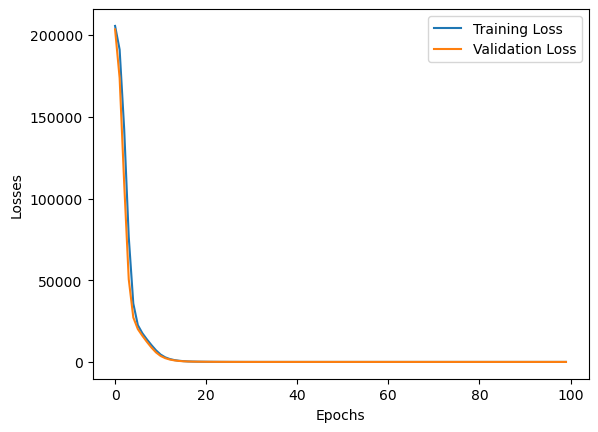

In [70]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [73]:
# load our best model
model.load_state_dict(torch.load("best_ANN_model.pt"))

<All keys matched successfully>

In [75]:
model.eval()
with torch.no_grad():
    train_pred = model(X_train_tensor)
    test_pred = model(X_test_tensor)

    train_loss = criterion(train_pred,y_train_tensor)
    test_loss = criterion(test_pred,y_test_tensor)

print("Training MSE : ",train_loss)
print("Tesing MSE : ",test_loss)

Training MSE :  tensor(19.8810)
Tesing MSE :  tensor(19.6270)


In [78]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test,test_pred)

print("R2 score = ",r2)

R2 score =  0.9309216811451417


In [80]:
predicted_df = pd.DataFrame(test_pred.numpy(),columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values,columns=["Actual Values"])

pd.concat([predicted_df,actual_df],axis=1)

,Predicted Values,Actual Values
0,474.602448,477.50
1,455.549286,456.64
2,451.703186,449.07
3,432.147400,436.42
4,455.598389,455.50
...,...,...
1909,455.711243,459.96
1910,480.502747,480.74
1911,448.194489,442.40
1912,467.273254,467.28
